# Powering Productivity: Sustainability Challenges and Economic Performance in the Age of AI Infrastructure
## ***Can the Environmental Costs of AI Infrastructure Be Reconciled with Economic Productivity Gains? Evidence from a Cross-Country Panel Analysis***

## Final Submission Notebook

## **Keziah AIKPO** 

##  22600200

##  Masters in Economics, Data and Transition

##  CY Cergy Paris Université

## Monday 11th May, 2026

-----

## Executive Summary

As far as it is known, Artificial Intelligence (AI) is a force in terms of economic growth, productivity improvement, digital transformation and techonological advancements. However, the fast paced expansion AI infrastructure brings to the world which  accounts for datacentres and computing systems as well as electricity networks raises numerous concerns regarding the steadily increasing level of energy consumption and the sustainabiility and maintenance of the environment. These developments have generated a very  important policy and economic question that affects the indivdual on a global scale : can the environmental costs associated with AI infrastructure be reconciled with the productivity gains it promises to deliver?

This project intends to deeply investigate this question through a cross-country panel analysis covering 32 countries raging for the years between 2010 and 2021 specifically. Rather than just measuring AI adoption directly, the analysis focuses mainly on the infrastructure systems AI's development and deployment relies on. The empirical framework examines the relationships between Labour Productivity, Carbon Intensity, Electricity Consumption, Renewable Energy Share, and Carbon Taxation.

The use of two-way fixed effects panel regression models is applied as the study evaluates both environmental and economic outcomes. The environmental model examines the determinants of Carbon Intensity, while the productivity model investigates factors associated with Labour Productivity. The combination and measuring these models provides and understandable insight into whether cleaner energy systems can support economic performance while reducing environmental pressures.



# Table of Contents

## Project Overview
- Executive Summary

## Data and Methodology
1. Introduction
2. Data Sources
3. Data Preparation
4. Dataset Overview

## Empirical Analysis
5. Descriptive Statistics
6. Correlation Analysis
7. Environmental Model
8. Productivity Model

## Findings and Implications
9. Discussion
10. Conclusion

## Supporting Material
11. References

# 1. Introduction
# Research Question

## **Can the environmental costs of AI infrastructure be reconciled with economic productivity gains?**

# The Main Motivations of the Study:
* Growth of AI infrastructure
* Datacentre expansion
* Electricity demand
* Sustainability concerns
* Twin Transition perspective


# Contribution to the Study
* Cross-country panel analysis
* 32 countries
* 2010–2021
* Environmental and economic outcomes

# 2. Data Sources
## A Short List of the Data Sources Used in the Study

| Variable                | Source     | Unit     |
| ----------------------- | ---------- | -------- |
| Labour Productivity     | OECD       | Index    |
| Carbon Intensity        | Ember      | gCO₂/kWh |
| Renewable Share         | World Bank | %        |
| Electricity Consumption | IEA        | TWh      |
| Carbon Tax              | OECD       | €/tCO₂   |


# 3. Data Preparation

In [1]:
import pandas as pd
import numpy as np

master_panel = pd.read_csv("../DATA/CLEANED DATA SETS/master_panel.csv")

master_panel.head()

,Country,Year,Labour_Productivity,Carbon_Intensity,Electricity_Consumption,Renewable_Share,Carbon_Tax
0,Australia,2010,66.426834,775.67,220091.029,8.2,0
1,Australia,2011,68.341060,749.42,223451.837,8.3,0
2,Australia,2012,67.268910,746.99,222415.400,8.3,0
3,Australia,2013,69.426270,726.16,218899.242,9.2,0
4,Australia,2014,69.183320,734.18,225954.139,9.3,0


In [2]:
master_panel.shape

(369, 7)

In [3]:
master_panel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369 entries, 0 to 368
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  369 non-null    object 
 1   Year                     369 non-null    int64  
 2   Labour_Productivity      369 non-null    float64
 3   Carbon_Intensity         369 non-null    float64
 4   Electricity_Consumption  369 non-null    float64
 5   Renewable_Share          369 non-null    float64
 6   Carbon_Tax               369 non-null    int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 20.3+ KB


In [4]:
master_panel.describe()

,Year,Labour_Productivity,Carbon_Intensity,Electricity_Consumption,Renewable_Share,Carbon_Tax
count,369.000000,369.000000,369.000000,3.690000e+02,369.000000,369.000000
mean,2015.558266,60.236930,324.294607,2.906790e+05,24.218970,0.504065
std,3.455068,22.212461,209.922046,6.975428e+05,16.658624,0.500662
min,2010.000000,13.976612,25.920000,6.119861e+03,3.200000,0.000000
25%,2013.000000,40.649040,169.990000,3.897570e+04,11.600000,0.000000
50%,2016.000000,62.096140,296.920000,8.224175e+04,20.600000,1.000000
75%,2019.000000,75.334010,493.070000,2.481987e+05,31.300000,1.000000
max,2021.000000,144.203830,893.030000,4.042840e+06,82.900000,1.000000


# 4. Dataset Overview

In [5]:
print(f"Number of observations: {len(master_panel)}")
print(f"Number of countries: {master_panel['Country'].nunique()}")
print(f"Years covered: {master_panel['Year'].min()} - {master_panel['Year'].max()}")

Number of observations: 369
Number of countries: 32
Years covered: 2010 - 2021


# 5. Descriptive Statistics

In [6]:
descriptive_stats = master_panel[
    [
        'Labour_Productivity',
        'Carbon_Intensity',
        'Electricity_Consumption',
        'Renewable_Share',
        'Carbon_Tax'
    ]
].describe()

descriptive_stats

,Labour_Productivity,Carbon_Intensity,Electricity_Consumption,Renewable_Share,Carbon_Tax
count,369.000000,369.000000,3.690000e+02,369.000000,369.000000
mean,60.236930,324.294607,2.906790e+05,24.218970,0.504065
std,22.212461,209.922046,6.975428e+05,16.658624,0.500662
min,13.976612,25.920000,6.119861e+03,3.200000,0.000000
25%,40.649040,169.990000,3.897570e+04,11.600000,0.000000
50%,62.096140,296.920000,8.224175e+04,20.600000,1.000000
75%,75.334010,493.070000,2.481987e+05,31.300000,1.000000
max,144.203830,893.030000,4.042840e+06,82.900000,1.000000


# 6. Correlation Analysis

In [7]:
correlation_matrix = master_panel[
    [
        'Labour_Productivity',
        'Carbon_Intensity',
        'Electricity_Consumption',
        'Renewable_Share',
        'Carbon_Tax'
    ]
].corr()

correlation_matrix

,Labour_Productivity,Carbon_Intensity,Electricity_Consumption,Renewable_Share,Carbon_Tax
Labour_Productivity,1.000000,-0.395833,0.147580,0.178288,0.040157
Carbon_Intensity,-0.395833,1.000000,0.202100,-0.596476,-0.198611
Electricity_Consumption,0.147580,0.202100,1.000000,-0.270951,-0.162107
Renewable_Share,0.178288,-0.596476,-0.270951,1.000000,0.418758
Carbon_Tax,0.040157,-0.198611,-0.162107,0.418758,1.000000


Correlation Heatmap

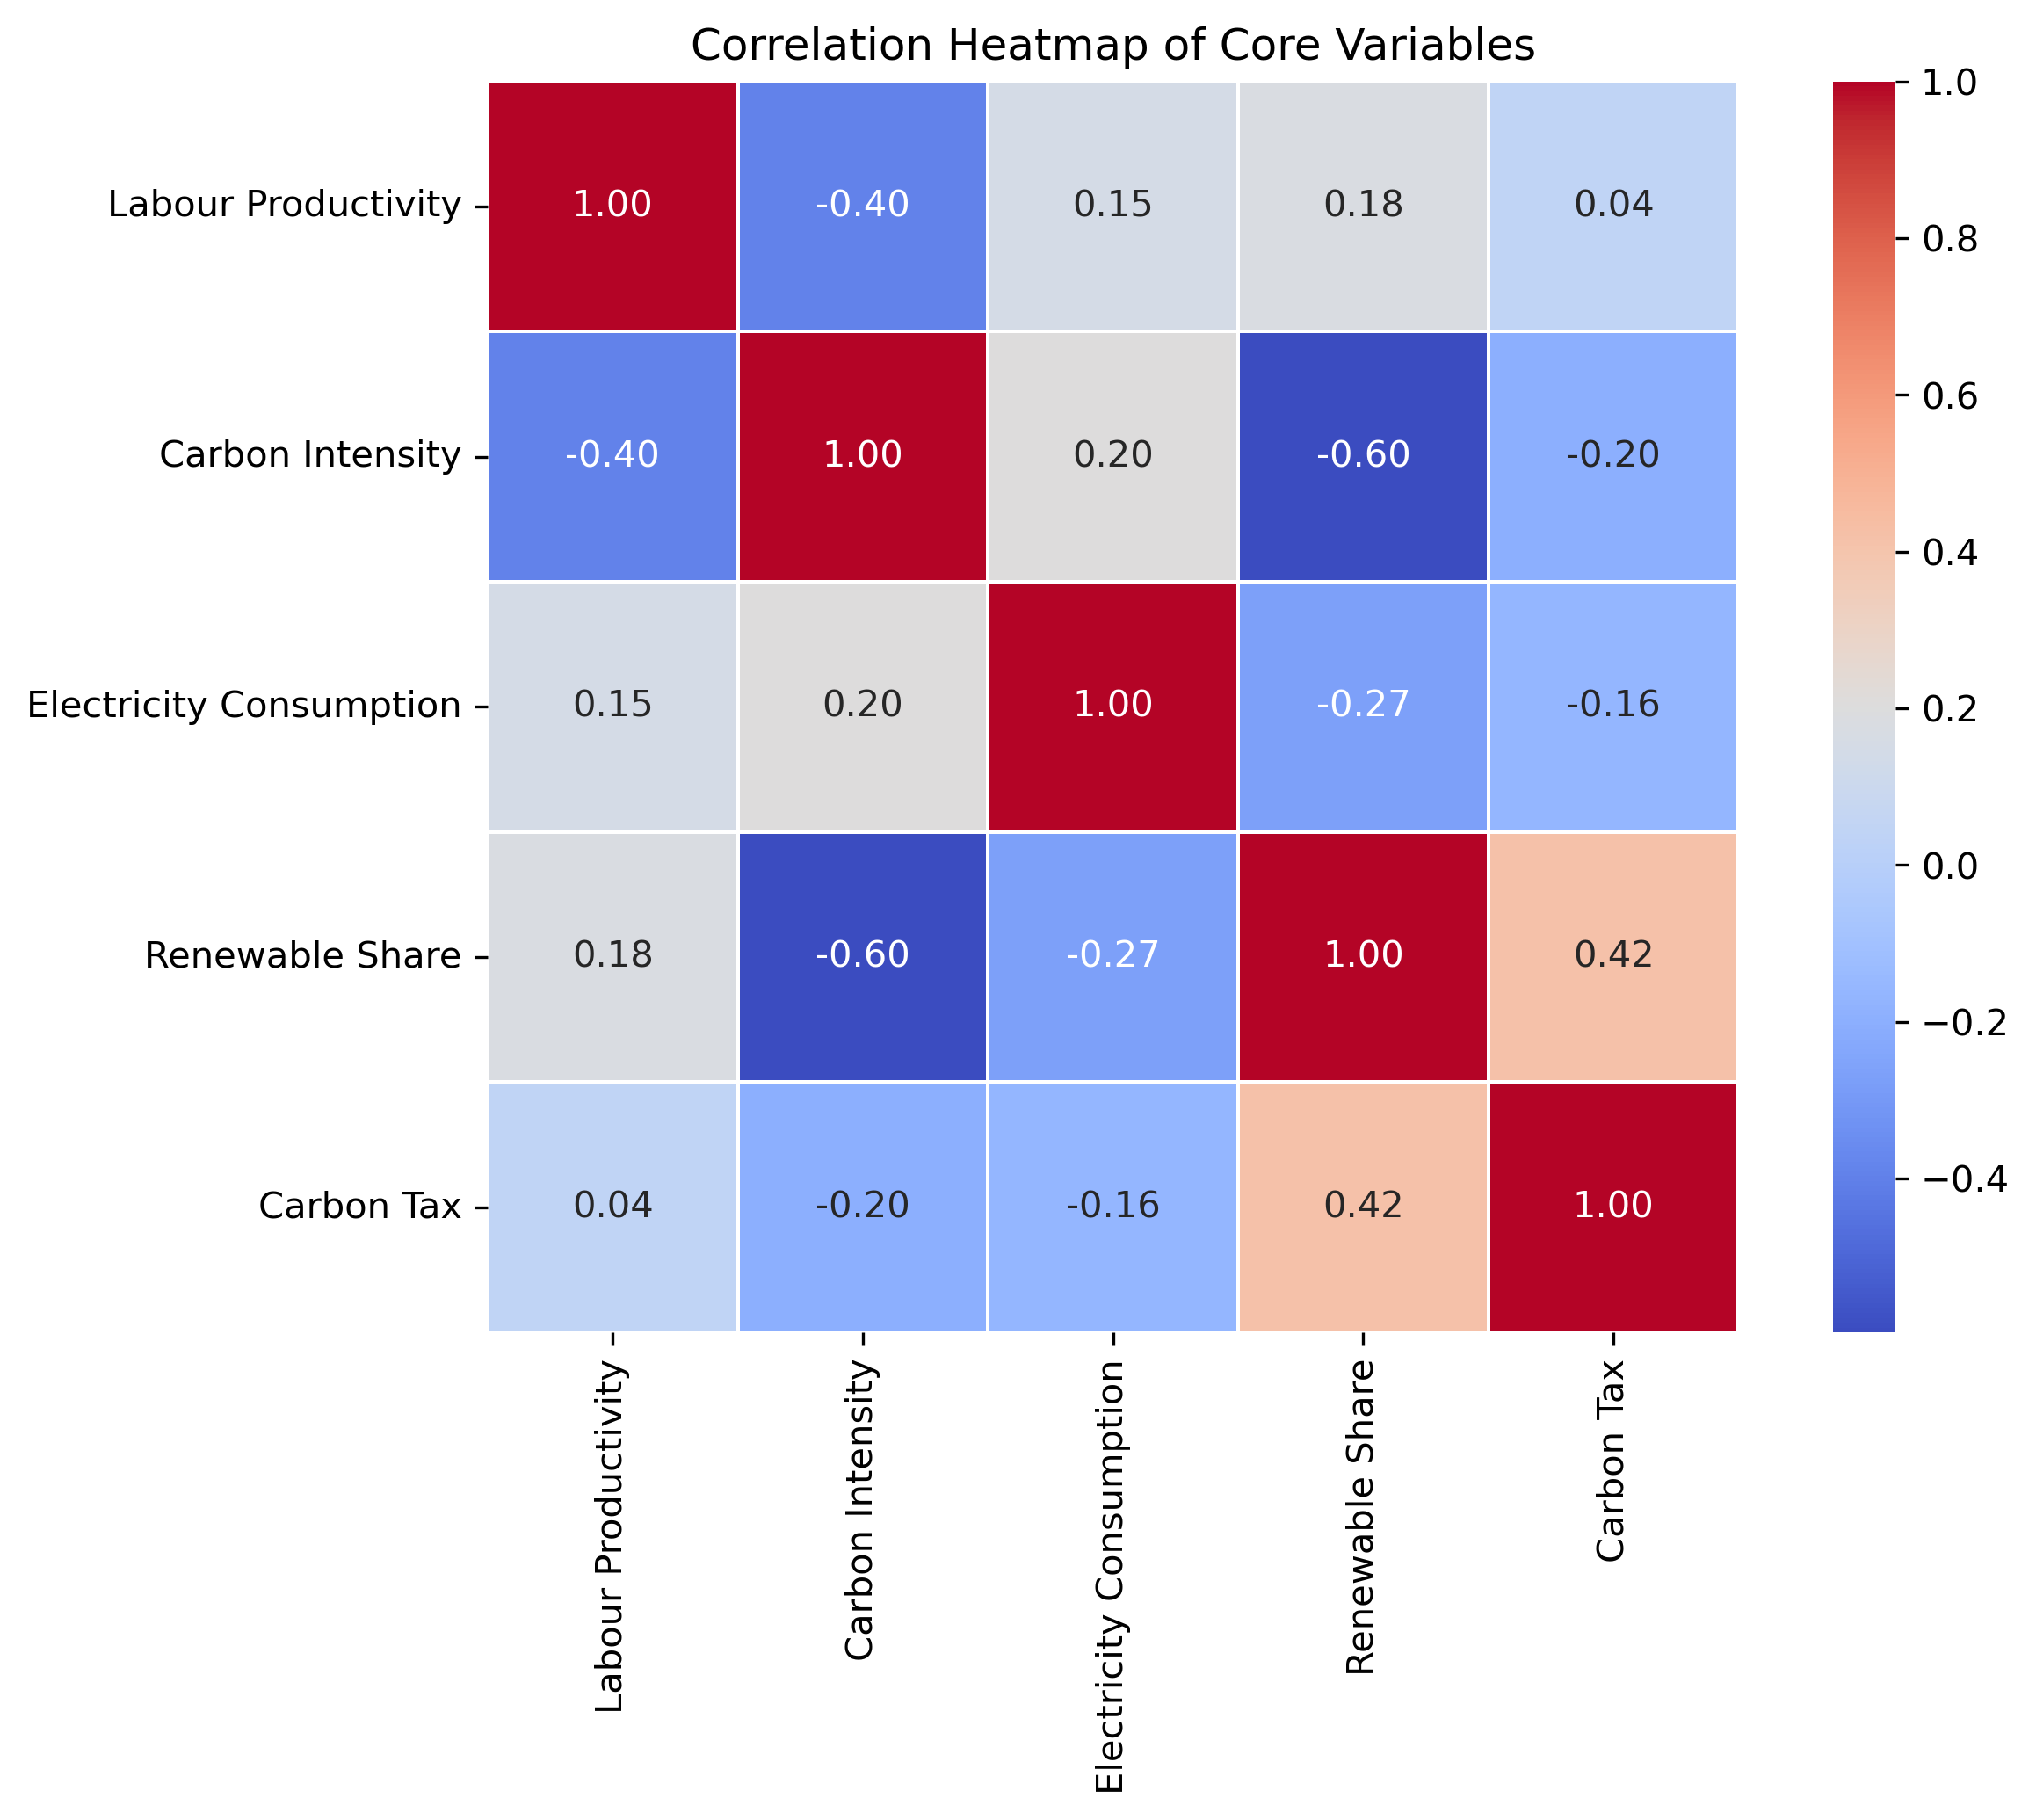

In [8]:
from IPython.display import Image

Image("Figure_6_Correlation_Heatmap.png")

### Interpretation of the Correlation Heatmap of Core Variables

This figure presents the correlation matrix for the main variables used in the analysis. The strongest relationship is between Renewable Share and Carbon Intensity with a negative correlation of approximately -0.596. The suggestion we get is that countries with a higher share of renewable energy tend to have lower carbon intensity in electricity generation.

The matrix also shows a negative relationship between Labour Productivity and Carbon Intensity. It is indicative of the understanding that more productive economies are not necessarily more carbon intensive. 

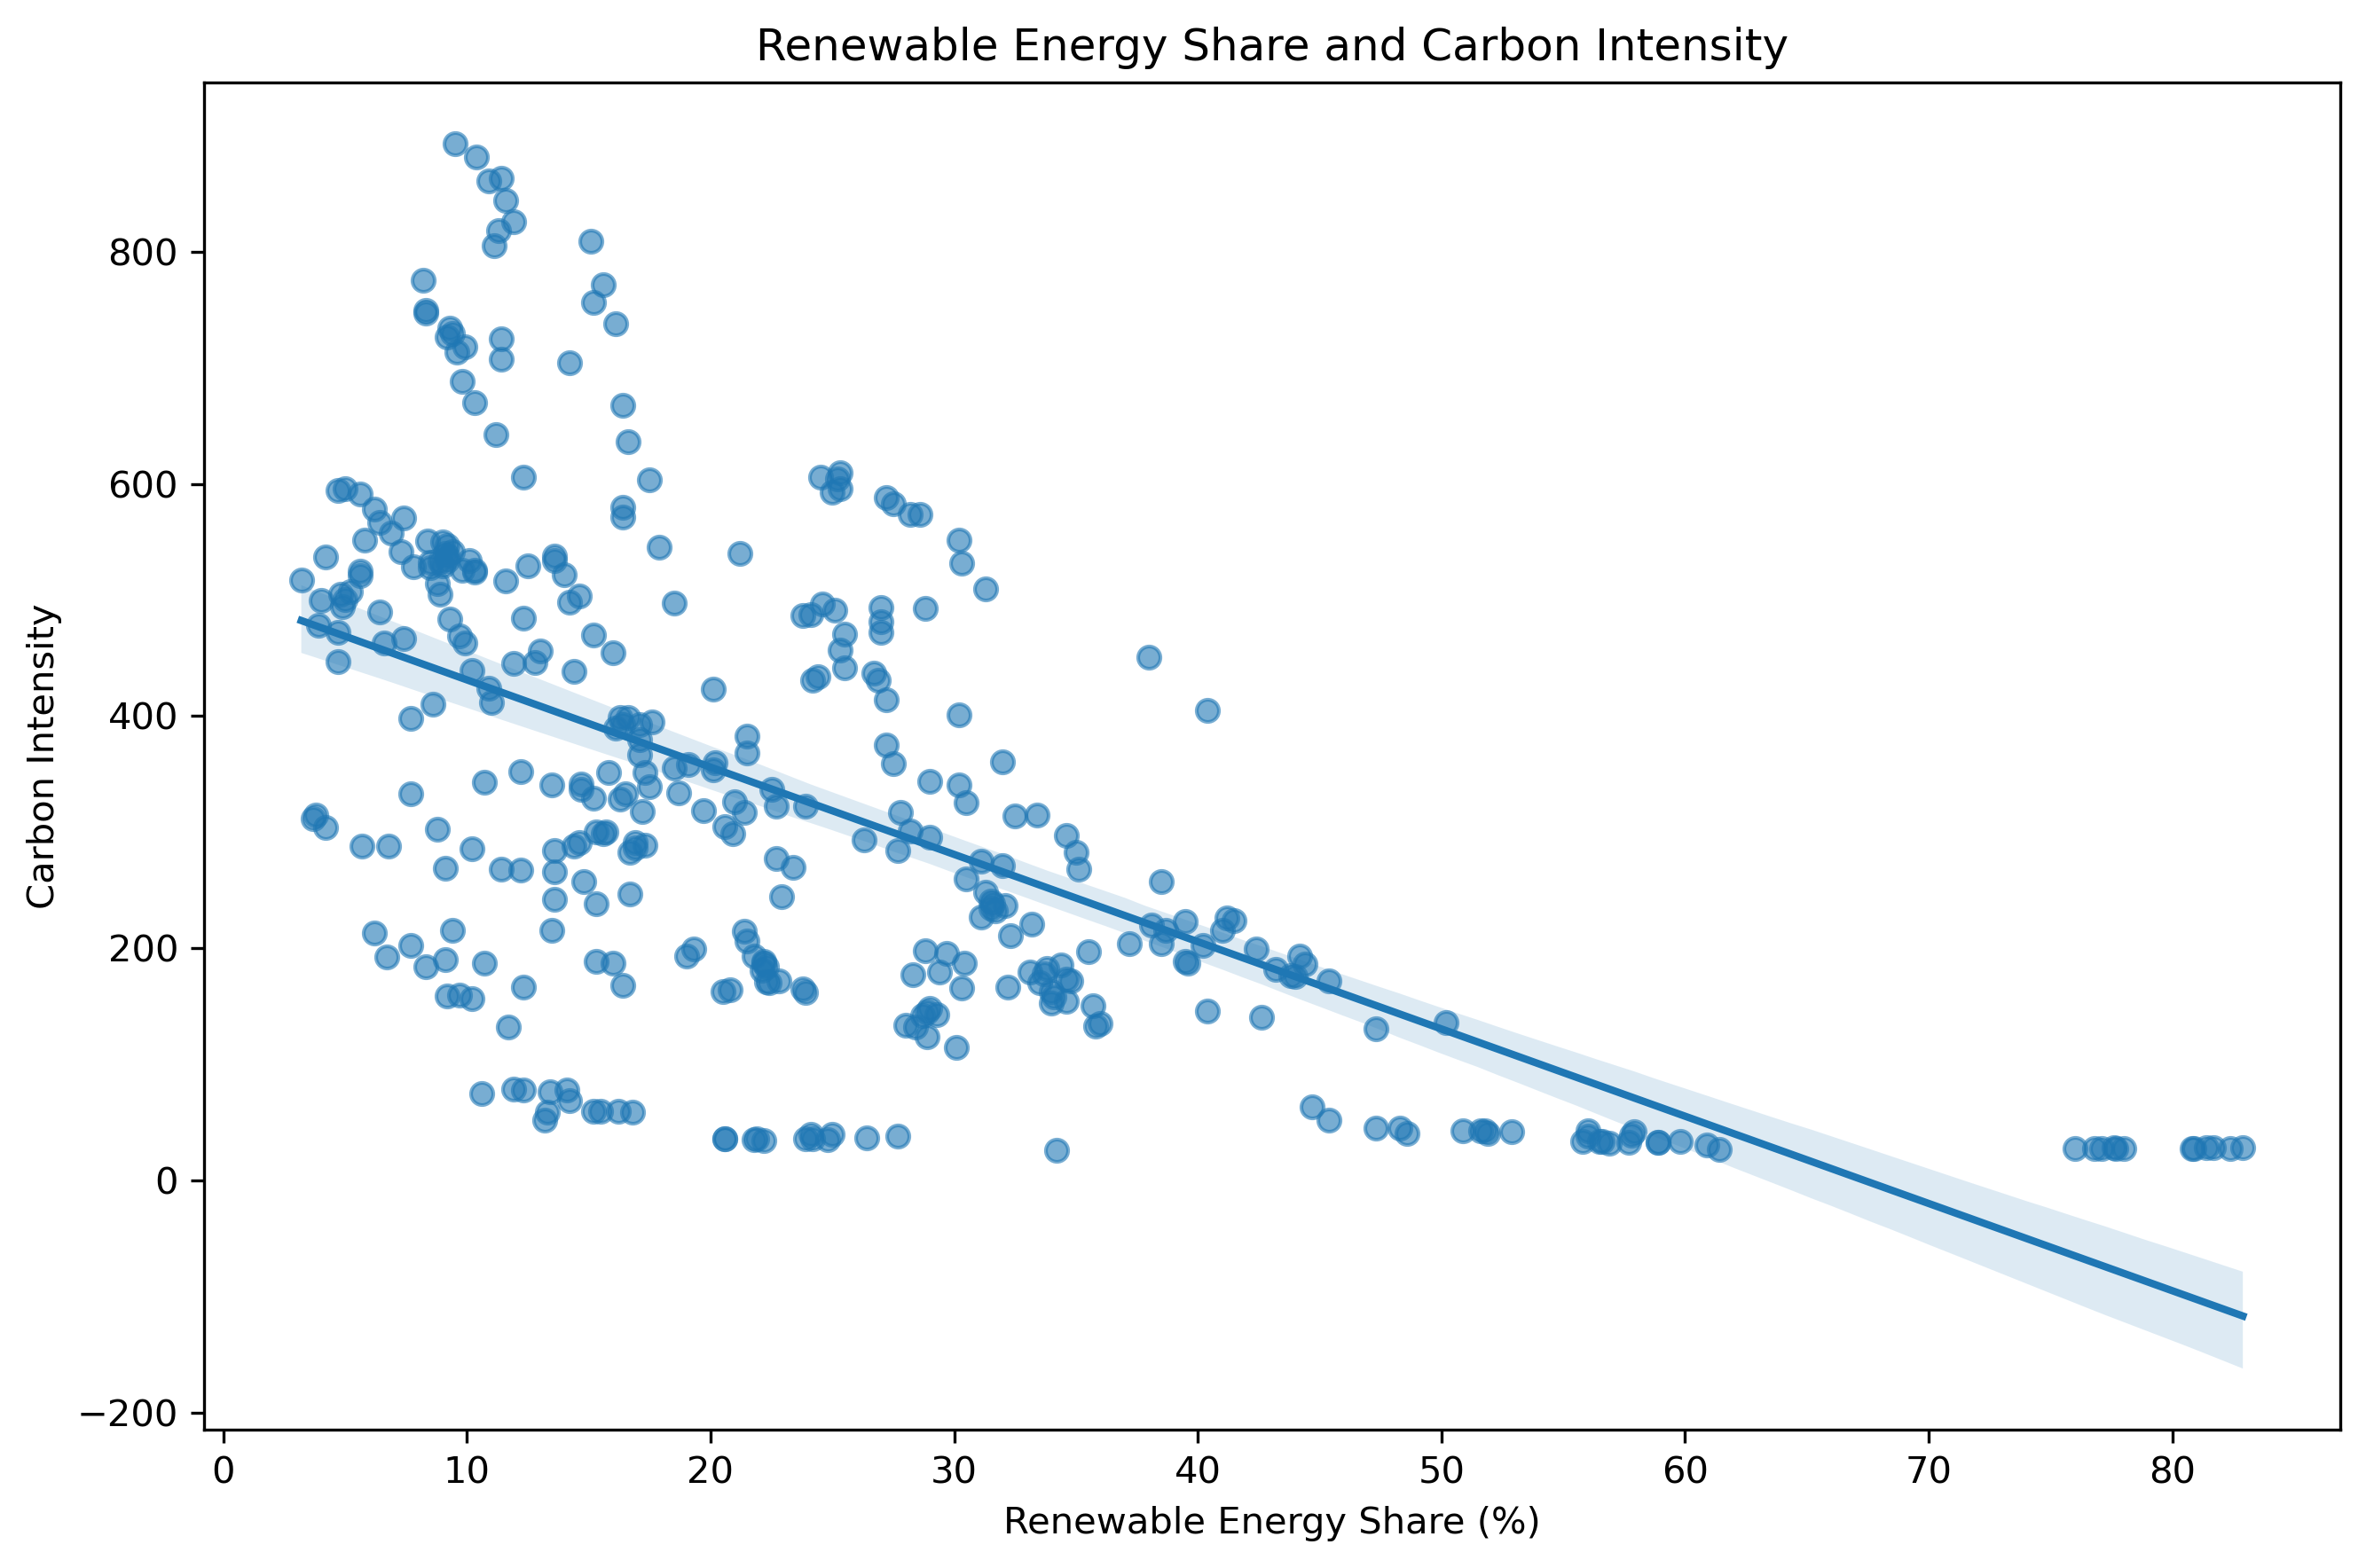

In [9]:
from IPython.display import Image

Image("Figure_7_Renewable_Share_vs_Carbon_Intensity.png")

### Interpretation of the Relationship Between Renewable Energy Share and Carbon Intensity

The downward pattern supports the core environmental argument of this study: countries with higher renewable energy shares are more likely to generate electricity with lower carbon intensity.

What this finding in particular suggests is that the environmental impact of rising electricity demand is strngly dependent on the energy mix. It is understoon that AI indeed depends on an excessive use of electricity. However the associated emissions AI produces can be reduced when electricity systems rely more heavily on renewable energy.

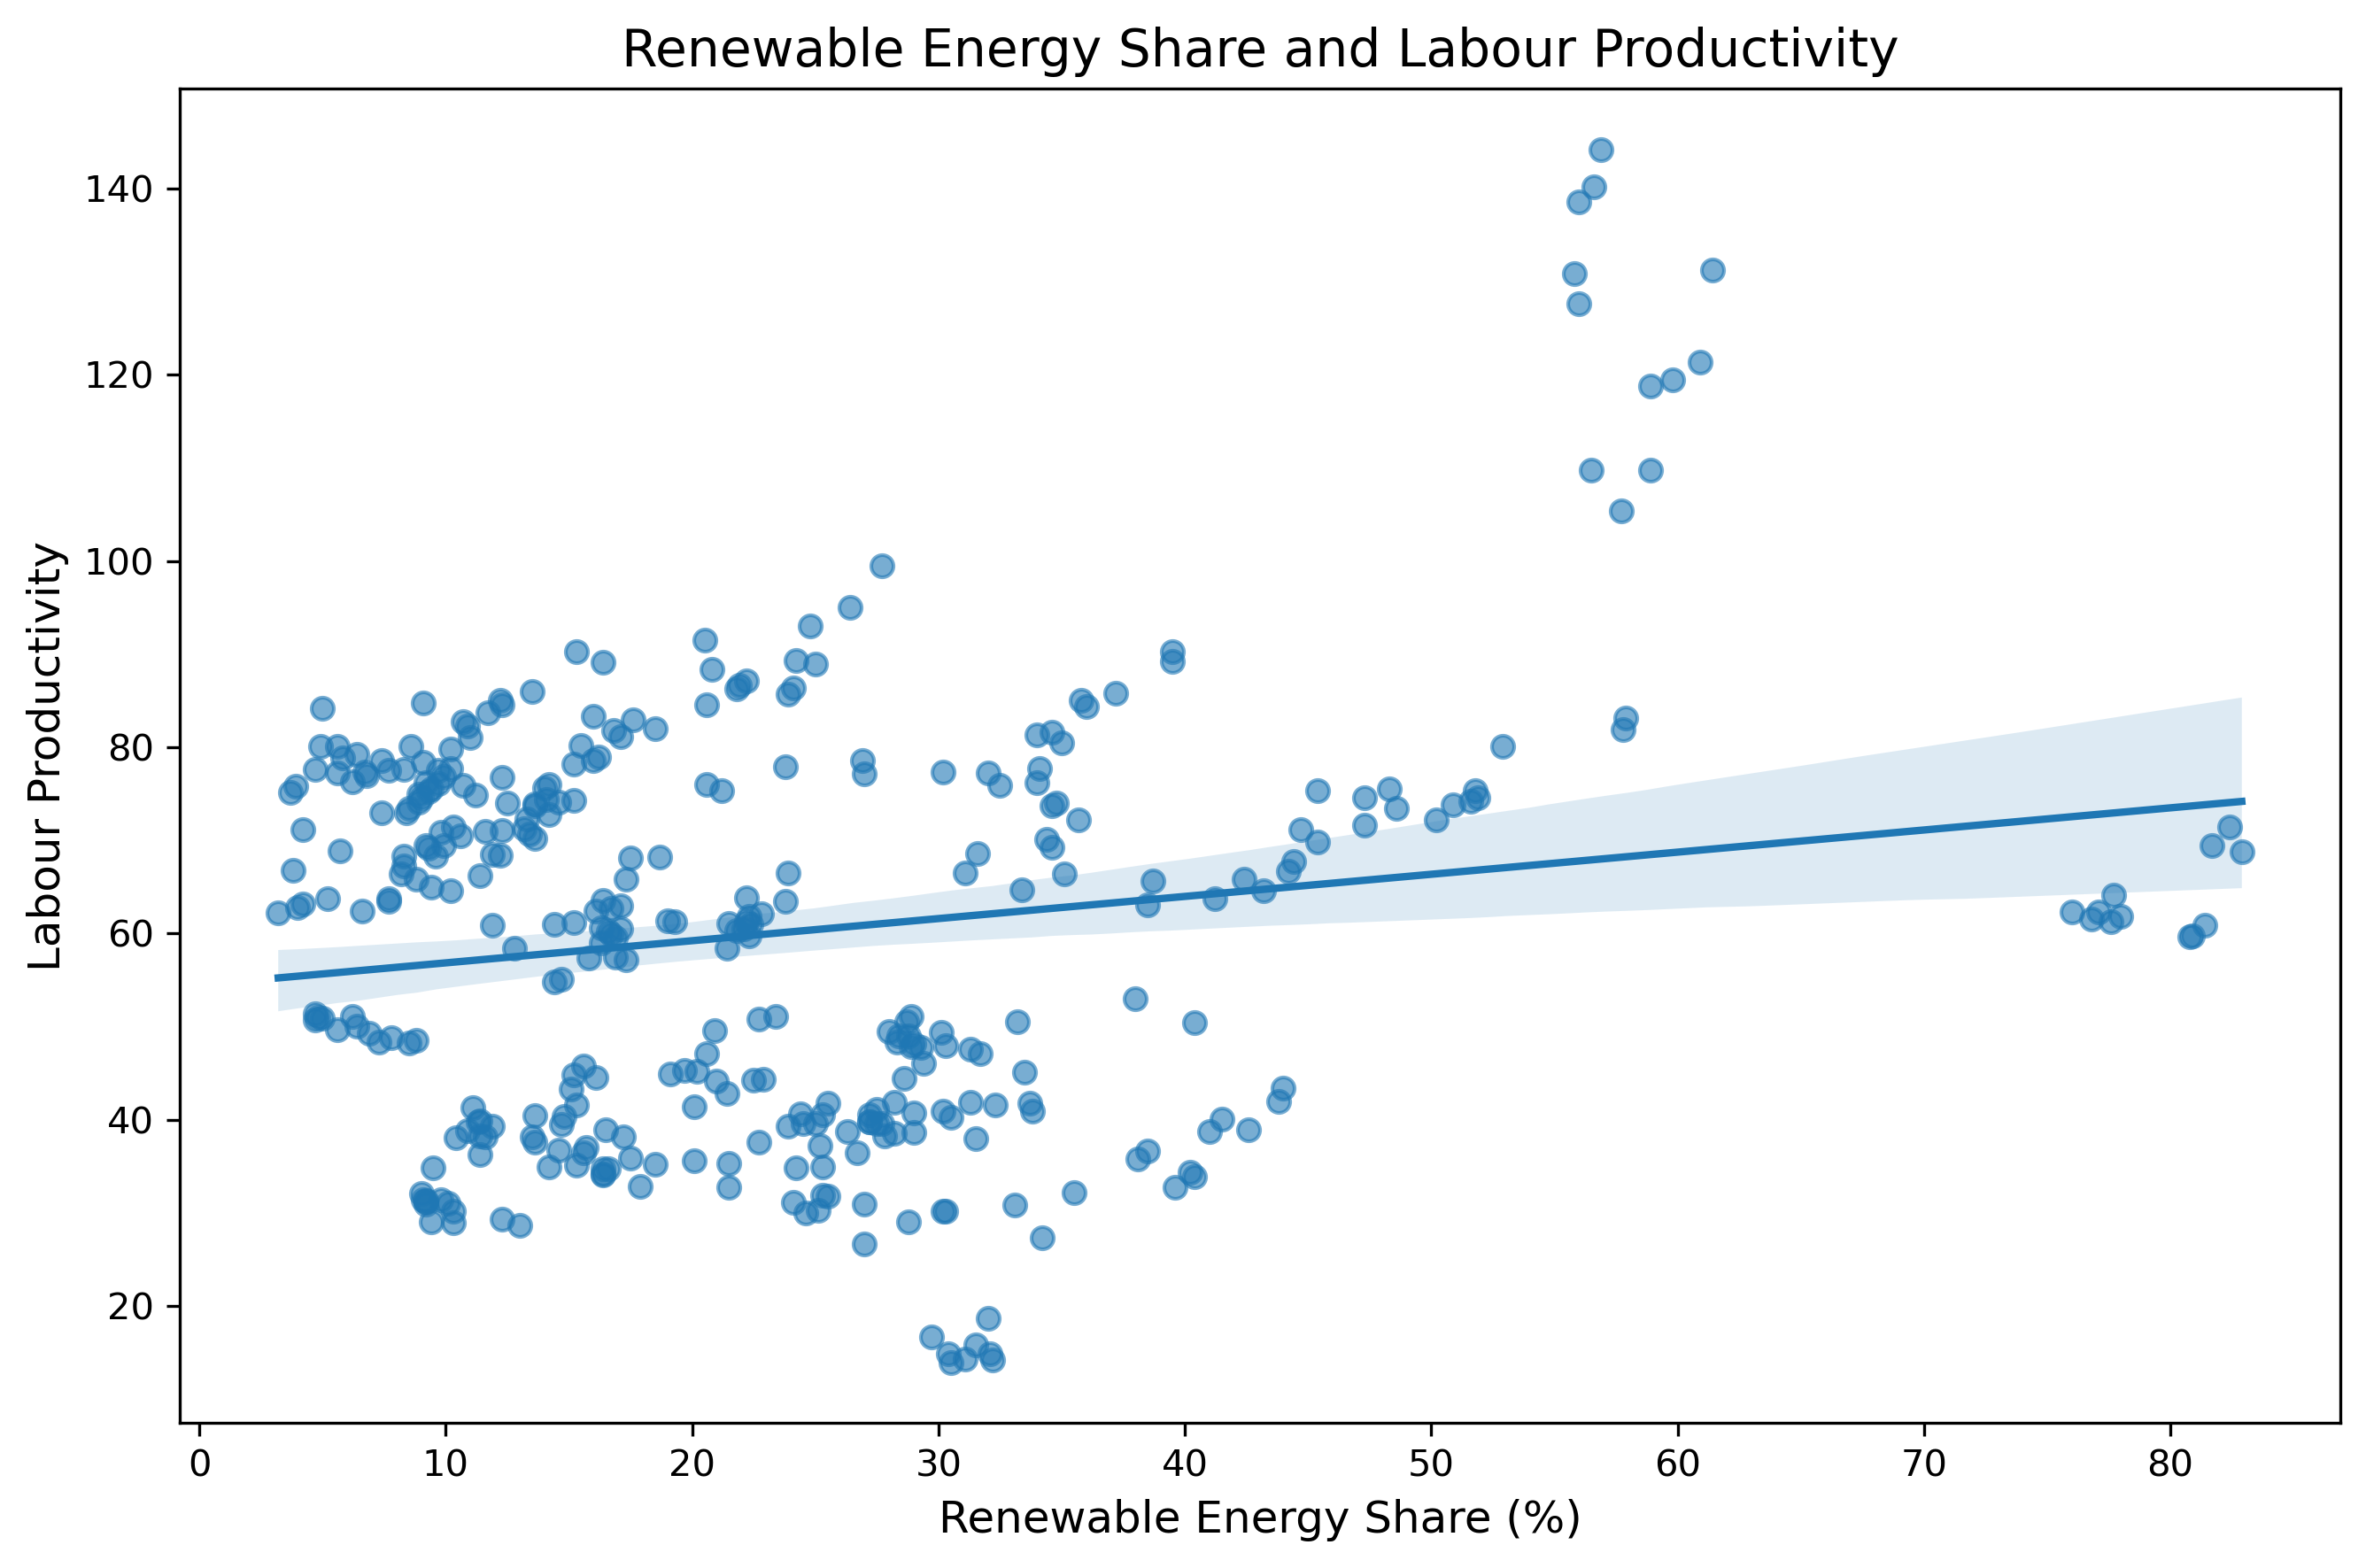

In [10]:
Image("Figure_8_Renewable_Share_vs_Labour_Productivity.png")

### Interpretation of the Relationship Between Renewable Share and Labour Productivity

This figure suggests a generally positive relationship, with countries exhibiting higher renewable energy shares often displaying higher levels of labour productivity.

Although the relationship is not perfectly linear, the pattern indicates that renewable energy adoption is not necessarily associated with lower economic performance. Instead the figure is suggesting that cleaner energy systems may coexist with strong productivity outcomes.

# 7. Environmental Model

This section aims to estimate the relationship between renewable energy, electricity consumption, carbon taxation, and carbon intensity. The goal is to examine whether cleaner energy systems are associated with lower environmental pressure in the context of AI infrastructure and digital expansion.

## 7.1 Model Specification

The environmental model is specified as follows:

**CarbonIntensity_it = β₀ + β₁RenewableShare_it + β₂ElectricityConsumption_it + β₃CarbonTax_it + α_i + γ_t + ε_it**

where i denotes countries, t denotes years, α_i captures country fixed effects, γ_t captures year fixed effects, and ε_it represents the error term. The dependent variable is Carbon Intensity, while the explanatory variables are Renewable Share, Electricity Consumption, and Carbon Tax.

In [11]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

# Set the panel structure
panel_data = master_panel.set_index(['Country', 'Year'])

# Define dependent and independent variables
y_env = panel_data['Carbon_Intensity']

X_env = panel_data[
    [
        'Renewable_Share',
        'Electricity_Consumption',
        'Carbon_Tax'
    ]
]

X_env = sm.add_constant(X_env)

# Estimate two-way fixed effects model
environmental_model = PanelOLS(
    y_env,
    X_env,
    entity_effects=True,
    time_effects=True
)

environmental_results = environmental_model.fit()

environmental_results

Dep. Variable:,Carbon_Intensity,R-squared:,0.2489
Estimator:,PanelOLS,R-squared (Between):,-0.0753
No. Observations:,369,R-squared (Within):,0.5028
Date:,"Mon, Jun 01 2026",R-squared (Overall):,-0.0594
Time:,17:08:31,Log-likelihood,-1812.1
Cov. Estimator:,Unadjusted,,
,,F-statistic:,35.687
Entities:,32,P-value,0.0000
Avg Obs:,11.531,Distribution:,"F(3,323)"
Min Obs:,1.0000,,
Max Obs:,12.000,F-statistic (robust):,35.687


## 7.2 Environmental Regression Results

In [12]:
import pandas as pd

environmental_results_table = pd.DataFrame({
    'Coefficient': environmental_results.params,
    'Standard Error': environmental_results.std_errors,
    'P-Value': environmental_results.pvalues
})

environmental_results_table

,Coefficient,Standard Error,P-Value
const,620.040946,49.884593,0.000000
Renewable_Share,-9.824005,0.957514,0.000000
Electricity_Consumption,-0.000188,0.000138,0.172083
Carbon_Tax,-6.031485,9.002995,0.503373


## 7.3 Interpretation of Environmental Results

This table presents the results of the environmental fixed-effects model. The results indicate that Renewable Share is strongly and negatively associated with Carbon Intensity. The coefficient of -9.824 is statistically significant at the 1 percent level (p < 0.001), suggesting that increases in the share of renewable energy are associated with substantial reductions in carbon intensity.

Electricity Consumption exhibits a negative coefficient but is not statistically significant (p = 0.172). This suggests that higher electricity use alone is not necessarily associated with greater carbon intensity once differences across countries and years are taken into account.

Carbon Tax also displays a negative coefficient, indicating a potential reduction in carbon intensity; however, the relationship is not statistically significant (p = 0.503).

The model is statistically significant (F-statistic = 35.687, p < 0.001) and explains approximately 24.9 percent of the variation in carbon intensity. The results provide strong evidence that renewable energy adoption plays a central role in reducing environmental pressure.

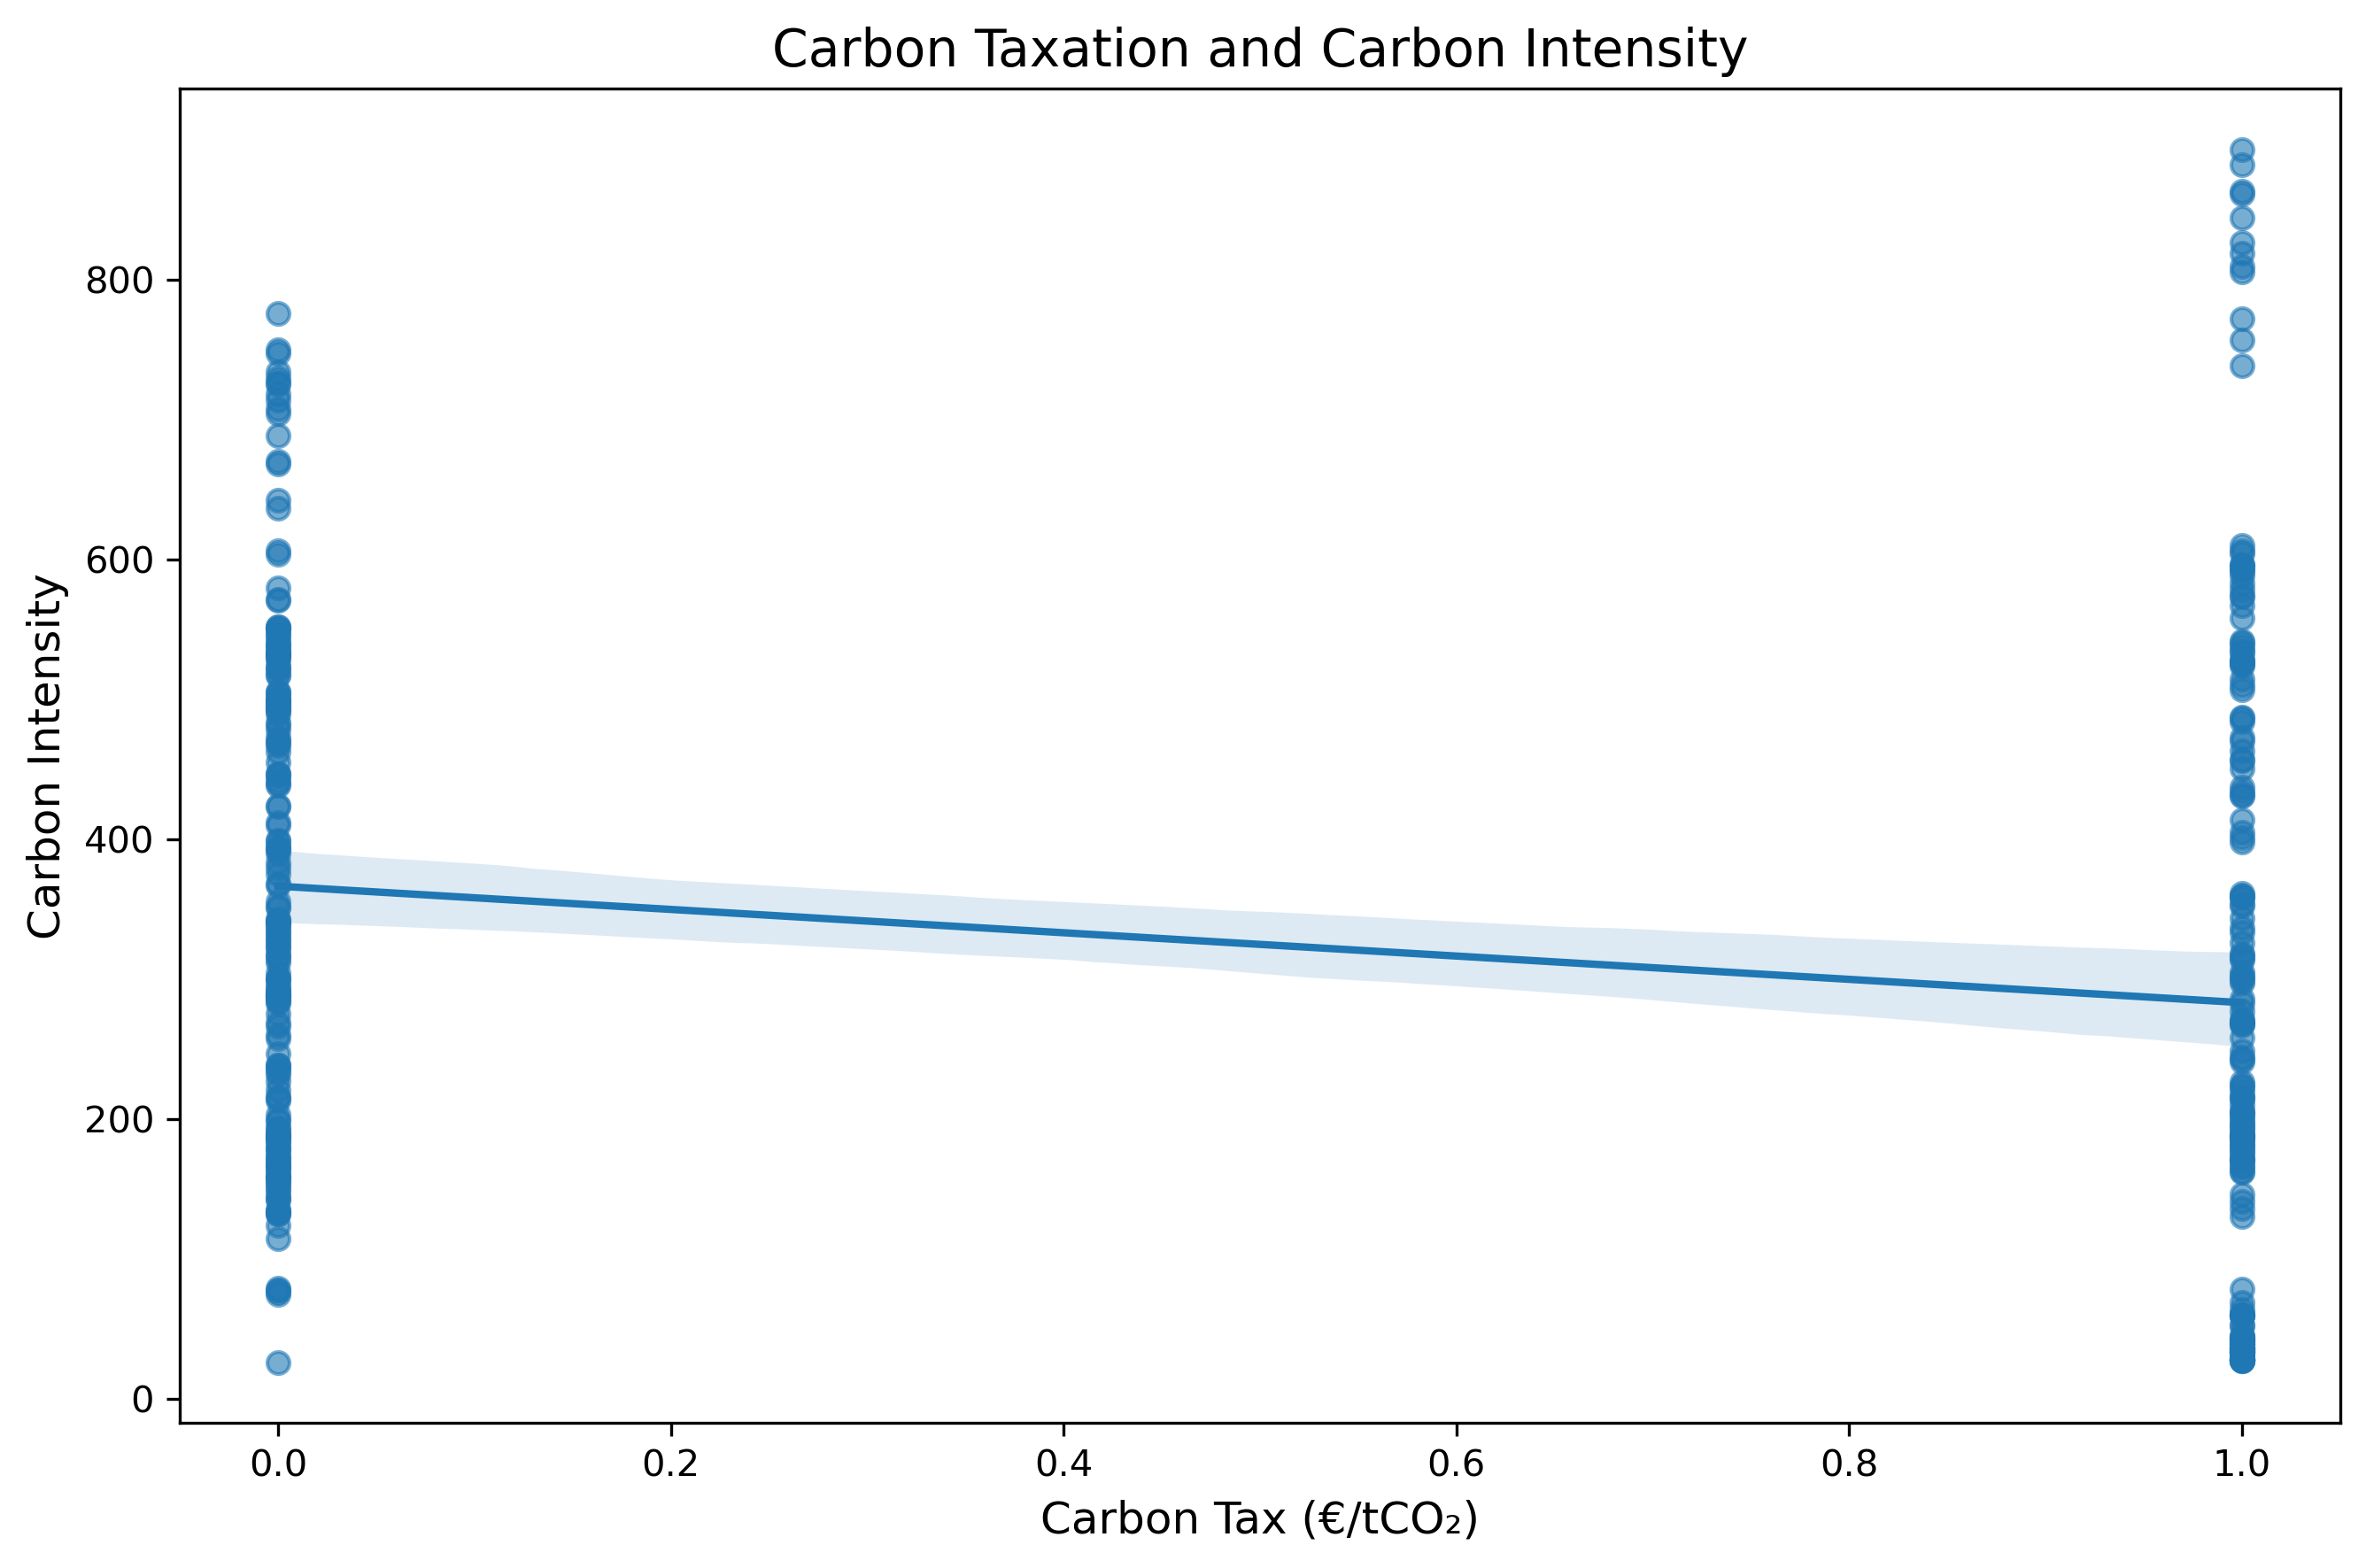

In [13]:
from IPython.display import Image

Image("Figure_9_Carbon_Taxation_vs_Carbon_Intensity.png")

### Interpretation of the Relationship Between Carbon Taxation and Carbon Intensity

While countries with carbon pricing mechanisms often exhibit lower carbon intensity, the relationship appears less consistent than the relationship observed for renewable energy. This visual observation is consistent with the regression results, which found no statistically significant effect of carbon taxation once country and year fixed effects were included.

# 8. Productivity Model

This section examines the relationship between environmental sustainability indicators and labour productivity. 

The objective is to assess whether cleaner energy systems are associated with stronger economic performance and whether environmental sustainability and productivity can coexist.

## 8.1 Model Specification

The productivity model is specified as follows:

**LabourProductivity_it = β₀ + β₁CarbonIntensity_it + β₂RenewableShare_it + β₃ElectricityConsumption_it + β₄CarbonTax_it + α_i + γ_t + ε_it**

where i denotes countries, t denotes years, α_i captures country fixed effects, γ_t captures year fixed effects, and ε_it represents the error term. Labour Productivity is the dependent variable, while Carbon Intensity, Renewable Share, Electricity Consumption, and Carbon Tax are included as explanatory variables.

In [14]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

panel_data = master_panel.set_index(['Country', 'Year'])

y_prod = panel_data['Labour_Productivity']

X_prod = panel_data[
    [
        'Carbon_Intensity',
        'Renewable_Share',
        'Electricity_Consumption',
        'Carbon_Tax'
    ]
]

X_prod = sm.add_constant(X_prod)

productivity_model = PanelOLS(
    y_prod,
    X_prod,
    entity_effects=True,
    time_effects=True
)

productivity_results = productivity_model.fit()

productivity_results

Dep. Variable:,Labour_Productivity,R-squared:,0.0711
Estimator:,PanelOLS,R-squared (Between):,-0.0273
No. Observations:,369,R-squared (Within):,0.2195
Date:,"Mon, Jun 01 2026",R-squared (Overall):,-0.0212
Time:,17:17:30,Log-likelihood,-948.47
Cov. Estimator:,Unadjusted,,
,,F-statistic:,6.1601
Entities:,32,P-value,0.0001
Avg Obs:,11.531,Distribution:,"F(4,322)"
Min Obs:,1.0000,,
Max Obs:,12.000,F-statistic (robust):,6.1601


## 8.2 Productivity Regression Results

In [15]:
productivity_results_table = pd.DataFrame({
    'Coefficient': productivity_results.params,
    'Standard Error': productivity_results.std_errors,
    'P-Value': productivity_results.pvalues
})

productivity_results_table

,Coefficient,Standard Error,P-Value
const,42.827622,5.848953,1.966649e-12
Carbon_Intensity,0.004768,0.005366,3.748360e-01
Renewable_Share,0.478844,0.106324,9.352796e-06
Electricity_Consumption,0.000015,0.000013,2.558049e-01
Carbon_Tax,-0.279609,0.868797,7.477864e-01


## 8.3 Interpretation of Productivity Results

This table presents the results of the productivity fixed-effects model. The findings indicate that Renewable Share is positively associated with Labour Productivity. The coefficient of 0.479 is statistically significant at the 1 percent level (p < 0.001), suggesting that countries with higher renewable energy shares tend to experience stronger productivity performance.

Carbon Intensity displays a positive coefficient; however, the relationship is not statistically significant (p = 0.375). This indicates that differences in carbon intensity do not appear to have a statistically meaningful relationship with labour productivity once country and year fixed effects are included.

Electricity Consumption also exhibits a positive coefficient but is not statistically significant (p = 0.256). Similarly, Carbon Tax displays a negative coefficient but remains statistically insignificant (p = 0.748).

The model is statistically significant (F-statistic = 6.160, p < 0.001) and explains approximately 7.1 percent of the variation in labour productivity. Although the explanatory power is lower than that of the environmental model, the results provide evidence that renewable energy adoption may contribute positively to economic performance.

# 9. Discussion

From the results achieved, there is substantial evidence that the environmental costs associated with AI infrastructure should be understood through the characteristics of the energy systems supporting digital technologies rather than through electricity consumption alone. For both regression models, Renewable Share proved to be the most important and consistent variable.

The environmental model demonstrated also that higher renewable energy shares are strongly associated with lower carbon intensity. The finding offers the suggestion that countries relying more heavily on renewable electricity generation are better positioned to reduce the environmental impacts associated with growing digital and AI infrastructure.

The productivity model provided complementary evidence to the evironmental model for the final result. Higher renewable energy shares were associated with stronger labour productivity outcomes, a clear indication that environmental sustainability and economic performance could be mutually reinforcing rather than conflicting objectives.

At the final observation, these findings support the central argument of the Twin Transition Framework. Digital transformation and environmental sustainability do not necessarily represent opposing policy goals. Instead, the environmental problems associated with AI infrastructure depend significantly on how electricity is generated. As AI systems, datacentres, digital technologies and computing systems continue to grow, investments in cleaner energy systems could allow countries to enjoy productivity gains while also limiting environmental harm.

The results therefore suggest that the challenge is not whether AI infrastructure should consume electricity, but whether the electricity supporting AI infrastructure is produced sustainably.

# 10. Conclusion

This study examined whether the environmental costs associated with AI infrastructure could be reconciled with economic productivity gains using a cross-country panel dataset covering 32 countries between 2010 and 2021.

The findings show that Renewable Share is consistently associated with both lower Carbon Intensity and higher Labour Productivity.On the other hand, Electricity Consumption and Carbon Tax did not exhibit statistically significant relationships in the final models. These results suggest that the sustainability implications of AI infrastructure depend less on electricity demand itself and more on the composition of the energy systems supplying that demand.

The analysis contributes also to the growing literature on AI infrastructure, sustainability, and digital transformation by providing empirical evidence supporting the chance of achieving both environmental and economic objectives simultaneously. Rather than viewing productivity growth and environmental sustainability as competing goals, the results indicate that cleaner energy systems could allow for countries to benefit from digital transformation while limiting environmental pressures and impact.

As AI adoption continues to move forward, policymakers face the challenge of ensuring that the infrastructure supporting AI is powered by sustainable energy sources. The findings propose that renewable energy expansion should play a critical role in determining whether future AI-driven productivity gains can be achieved in an environmentally sustainable manner.

# 11. References

Dataset Sources

- Ember. Electricity Carbon Intensity Dataset.
- International Energy Agency (IEA). Electricity Consumption Dataset.
- OECD. Labour Productivity Dataset.
- World Bank. Renewable Energy Share Dataset.
- OECD and European Commission. Carbon Tax and Carbon Pricing Data.